In [2]:
import numpy as np 
import cv2 
import matplotlib.pyplot as plt 

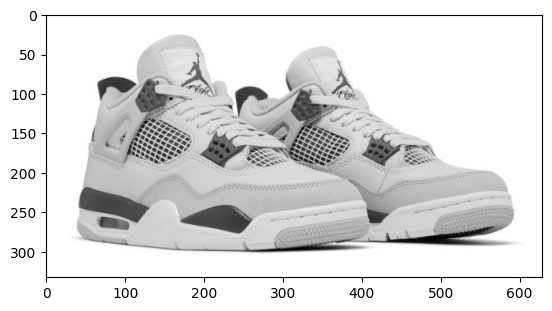

In [3]:
image = cv2.imread("data/shoes.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")

In [11]:
def add_salt_pepper_noise(image, probability = 0.3):
    noisy = image.copy()

    random = np.random.rand(*image.shape)

    noisy[random < probability / 2] = 0
    noisy[random > 1 - probability / 2] = 255

    return noisy

(333, 629)


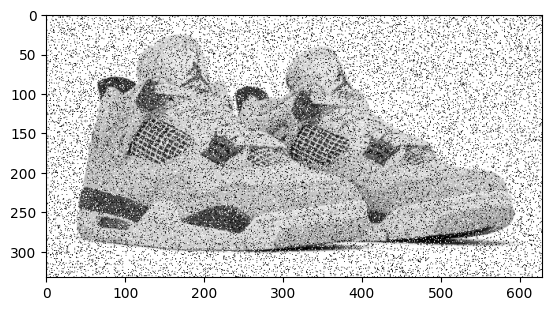

In [16]:
prob = 0.2

noisy = add_salt_pepper_noise(image, prob) 
print(noisy.shape)

plt.imshow(noisy, cmap="gray")

In [14]:
def median_filter(image, kernel_size = 3):
    image = image.copy()
    image = cv2.copyMakeBorder(image, int(kernel_size / 2), int(kernel_size / 2), int(kernel_size / 2), int(kernel_size / 2), cv2.BORDER_REPLICATE)
    print(image.shape)
    currentImage = image[0:kernel_size, 0:kernel_size]
    for i in range(image.shape[0] - kernel_size):
        for j in range(image.shape[1] - kernel_size):
            currentImage = image[i:i + kernel_size, j:j + kernel_size]
            arr1 = currentImage.flatten()  
            arr1.sort();
            median = arr1[int(len(arr1) / 2)];
            image[i + int(kernel_size / 2), j + int(kernel_size / 2)] = median
    
    return image;

(335, 631)


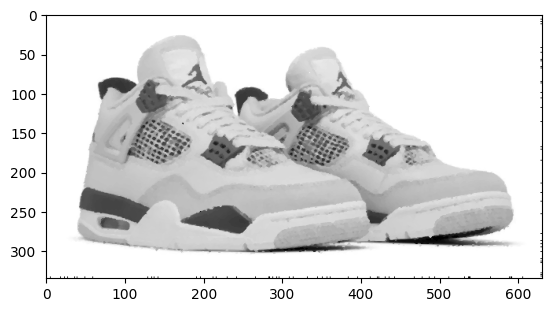

In [15]:
filterImage = median_filter(noisy, 3)
plt.imshow(filterImage, cmap="gray")

In [17]:
def mean_filter(image, kernel_size = 3):
    image = image.copy()
    image = cv2.copyMakeBorder(image, int(kernel_size / 2), int(kernel_size / 2), int(kernel_size / 2), int(kernel_size / 2), cv2.BORDER_REPLICATE)

    currentImage = image[0:kernel_size, 0:kernel_size]
    for i in range(image.shape[0] - kernel_size):
        for j in range(image.shape[1] - kernel_size):
            currentImage = image[i:i + kernel_size, j:j + kernel_size]
            mean = np.mean(currentImage)
            image[i + int(kernel_size / 2), j + int(kernel_size / 2)] = mean
    return image;

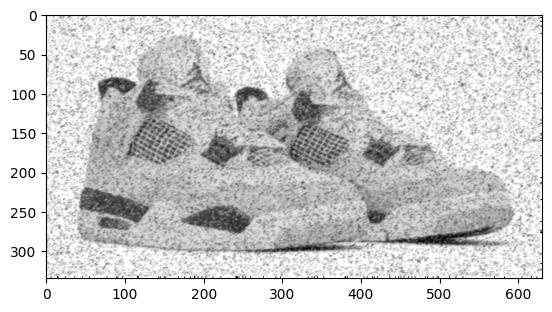

In [18]:
filterMean = mean_filter(noisy, 3)
plt.imshow(filterMean, cmap="gray")